# 08 · Recorded capability results and null floors

Load the repository's recorded results from `website/data/results.json` and plot each capability against its matched null. Model order differs across capabilities, so these are evidence summaries rather than a single universal size-scaling claim. The provenance and interpretation travel with the JSON.


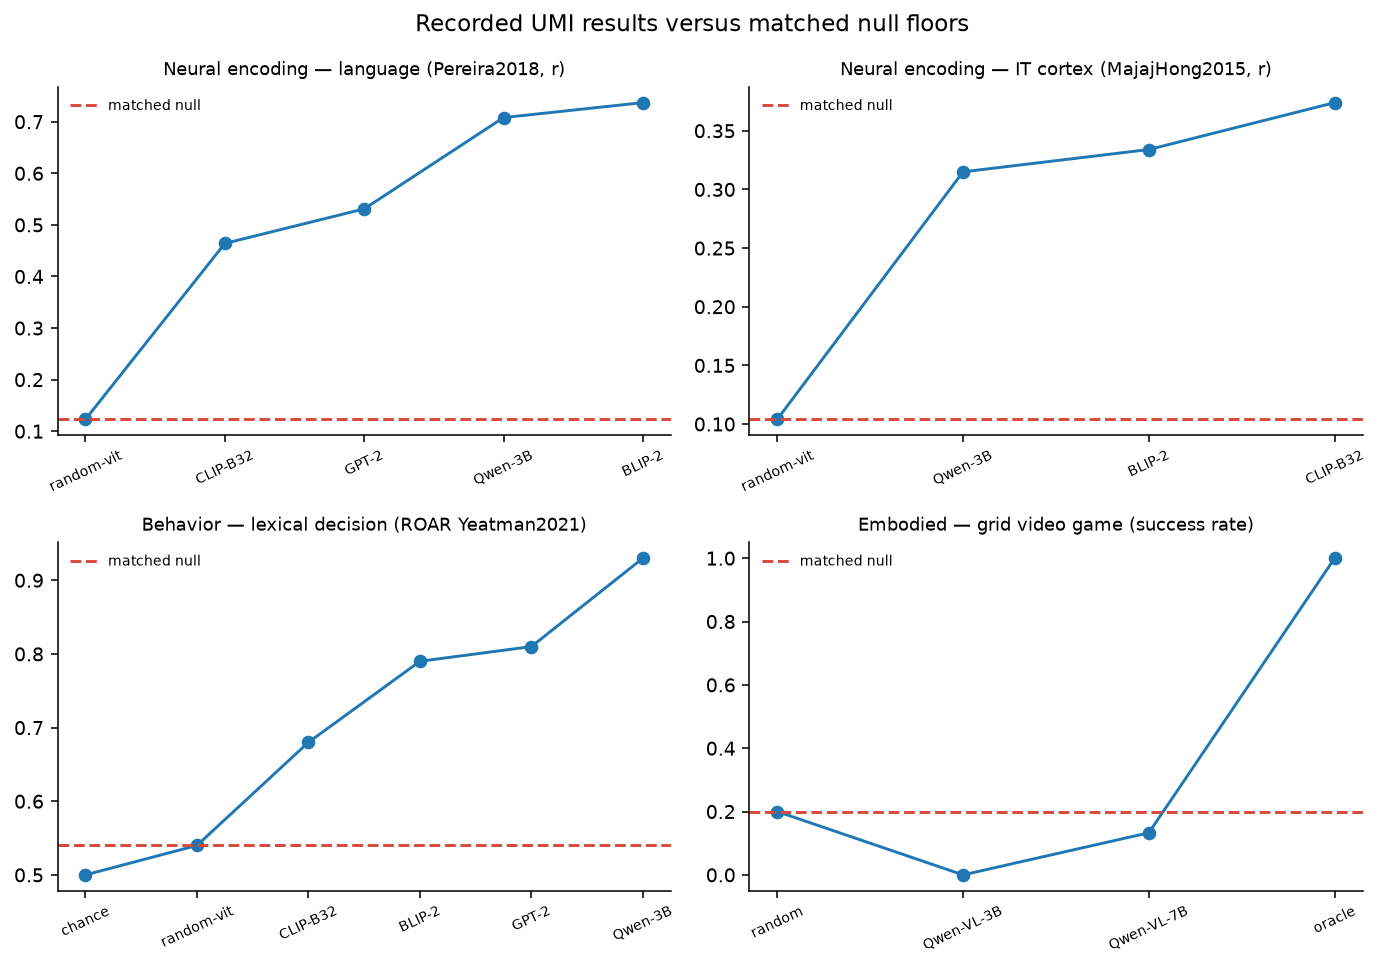

source: ../website/data/results.json
provenance: Neural/behavioral scores reproduced bit-for-bit on v1.5 from the v1 baselines; game scores from scripts/vlm_game; figures from brainscore.visualization.
language_encoding best= 0.737 null= 0.123
it_encoding best= 0.374 null= 0.104
behavior_roar best= 0.93 null= 0.54
embodied_game best= 1.0 null= 0.2


In [1]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

import json
from pathlib import Path
import tempfile
from IPython.display import Image, display
import matplotlib.pyplot as plt

candidates = [Path('../website/data/results.json'), Path('unified/website/data/results.json')]
results_path = next(path for path in candidates if path.exists())
record = json.loads(results_path.read_text())
selected = ['language_encoding', 'it_encoding', 'behavior_roar', 'embodied_game']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for axis, key in zip(axes.ravel(), selected):
    item = record['scaling'][key]
    axis.plot(item['models'], item['scores'], '-o')
    axis.axhline(item['null_floor'], color='#d8483b', linestyle='--', label='matched null')
    axis.set_title(item['capability'], fontsize=9)
    axis.tick_params(axis='x', rotation=25, labelsize=7)
    axis.spines[['top', 'right']].set_visible(False)
    axis.legend(frameon=False, fontsize=7)
fig.suptitle('Recorded UMI results versus matched null floors')
fig.tight_layout()
out_png = Path(tempfile.gettempdir()) / 'recorded_capability_results.png'
fig.savefig(out_png, dpi=140, bbox_inches='tight')
plt.close(fig)
display(Image(str(out_png)))
print('source:', results_path)
print('provenance:', record['meta']['provenance'])
for key in selected:
    item = record['scaling'][key]
    print(key, 'best=', max(item['scores']), 'null=', item['null_floor'])


**Reading it:** neural and behavioral results clear their matched nulls, while the recorded visual-VLM game results do not. That below-null result is retained because it identifies a capability failure rather than validating one. Compare models only within a panel; the panels use different model sets and orderings.